# 1. Single-System Data Preprocessing

This notebook loads, audits, cleans and saves the merged data of one PV system (`SYSTEM_ID`). The merged source remains unchanged; the cleaned result is saved separately.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "data" / "merged").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the thesis project root.")

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/raul/Desktop/solar-data-all/thesis


## 1. Load the merged source

Load the selected system’s merged CSV without changing sensor values. The only conversion here is parsing `datetime`; the raw file remains untouched.

In [2]:
# Select the system and load its merged CSV.
SYSTEM_ID = 4
MERGED_DIR = PROJECT_ROOT / "data" / "merged"
INPUT_PATH = MERGED_DIR / f"system_{SYSTEM_ID}_merged.csv"
if not INPUT_PATH.is_file():
    raise FileNotFoundError(f"Merged data not found: {INPUT_PATH}")

raw_df = pd.read_csv(INPUT_PATH, low_memory=False)
if "datetime" not in raw_df.columns:
    raise KeyError(f"No datetime column found in {INPUT_PATH.name}.")
raw_df["datetime"] = pd.to_datetime(raw_df["datetime"], errors="coerce")

print(f"System selected: {SYSTEM_ID}")
print(f"Loaded merged input: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
display(raw_df.head(5))

System selected: 4
Loaded merged input: 4,206,520 rows x 12 columns


,system_id,datetime,ac_current__319,ac_power__315,ac_voltage__318,ambient_temp__320,das_temp__325,dc_pos_current__317,dc_pos_voltage__316,dc_power__314,module_temp_1__321,poa_irradiance__313
0,4,2007-08-26 00:00:00,-0.106,-0.006,118.753,22.395,23.670,0.008,0.472,0.004,21.588,14.0
1,4,2007-08-26 00:15:00,-0.108,-0.029,118.689,22.606,23.518,0.008,0.516,0.004,21.972,13.0
2,4,2007-08-26 00:30:00,-0.106,-0.029,118.737,22.939,23.502,0.008,0.476,0.004,21.920,13.0
3,4,2007-08-26 00:45:00,-0.105,-0.020,119.011,23.013,23.638,0.008,0.523,0.004,22.013,12.0
4,4,2007-08-26 01:00:00,-0.106,-0.021,118.950,22.614,23.677,0.008,0.486,0.004,21.414,13.0


## 2. Select the system and columns

Keep only rows for `SYSTEM_ID`. By default every column is kept; set `COLUMNS_TO_KEEP` to narrow the analysis. `system_id`, `datetime` and the DC-power column `dc_power_column` are always kept because later stages need them.

In [3]:
# Choose optional analysis columns for this system; None keeps all columns.
COLUMNS_TO_KEEP = None

dc_power_column = "dc_power__314"
system_df = raw_df.loc[raw_df["system_id"].eq(SYSTEM_ID)].copy()
if system_df.empty:
    raise ValueError(f"No rows for system_id={SYSTEM_ID} in {INPUT_PATH.name}.")
if COLUMNS_TO_KEEP is not None:
    keep = dict.fromkeys(["system_id", "datetime", dc_power_column, *COLUMNS_TO_KEEP])
    system_df = system_df[list(keep)].copy()

print(f"Projected system data: {system_df.shape[0]:,} rows x {system_df.shape[1]} columns")
print(f"Primary DC power column: {dc_power_column}")
print(f"Columns available for this run: {system_df.columns.tolist()}")

Projected system data: 4,206,520 rows x 12 columns
Primary DC power column: dc_power__314
Columns available for this run: ['system_id', 'datetime', 'ac_current__319', 'ac_power__315', 'ac_voltage__318', 'ambient_temp__320', 'das_temp__325', 'dc_pos_current__317', 'dc_pos_voltage__316', 'dc_power__314', 'module_temp_1__321', 'poa_irradiance__313']


## 3. Inspect raw data quality

Review missing values, sentinel codes, constant columns, duplicate rows/timestamps, and invalid timestamps before cleaning. These reports describe the projected raw data; no rows or feature columns have been removed yet.

In [4]:
# Sentinel codes that represent invalid sensor readings (replaced in stage 5).
SENTINEL_VALUES = (-99999, -7999)

numeric_data = system_df.select_dtypes(include="number")
raw_missing_report = pd.DataFrame(
    {
        "missing_count": system_df.isna().sum(),
        "missing_percent": (system_df.isna().mean() * 100).round(2),
    }
).sort_values("missing_percent", ascending=False)
raw_sentinel_report = pd.DataFrame(
    {str(value): numeric_data.eq(value).sum() for value in SENTINEL_VALUES}
)
raw_sentinel_report = raw_sentinel_report.loc[raw_sentinel_report.any(axis=1)]
constant_columns = numeric_data.columns[numeric_data.nunique() <= 1].tolist()

print("Missing values by column:")
display(raw_missing_report)
print("Sentinel values by column:")
display(raw_sentinel_report)
print("Constant numeric columns:")
print(constant_columns)
print(f"Duplicate rows: {system_df.duplicated().sum():,}")
print(f"Invalid timestamps: {system_df['datetime'].isna().sum():,}")
print(f"Duplicate timestamps: {system_df['datetime'].dropna().duplicated().sum():,}")

Missing values by column:


,missing_count,missing_percent
poa_irradiance__313,225513,5.36
system_id,0,0.00
ac_current__319,5,0.00
datetime,0,0.00
ac_power__315,4,0.00
ac_voltage__318,5,0.00
das_temp__325,8,0.00
ambient_temp__320,5,0.00
dc_pos_current__317,4,0.00
dc_pos_voltage__316,2,0.00


Sentinel values by column:


,-99999,-7999
ambient_temp__320,0,12
dc_pos_current__317,0,1
dc_power__314,0,1
module_temp_1__321,0,518418
poa_irradiance__313,0,44913


Constant numeric columns:
['system_id']


Duplicate rows: 0
Invalid timestamps: 0


Duplicate timestamps: 0


## 4. Visualize raw DC power over time

This plot uses the projected data before cleaning. The full-range panel keeps extreme values visible; the second panel zooms to the central 99% of the sampled readings. The sample is only for display and does not alter the data used below.

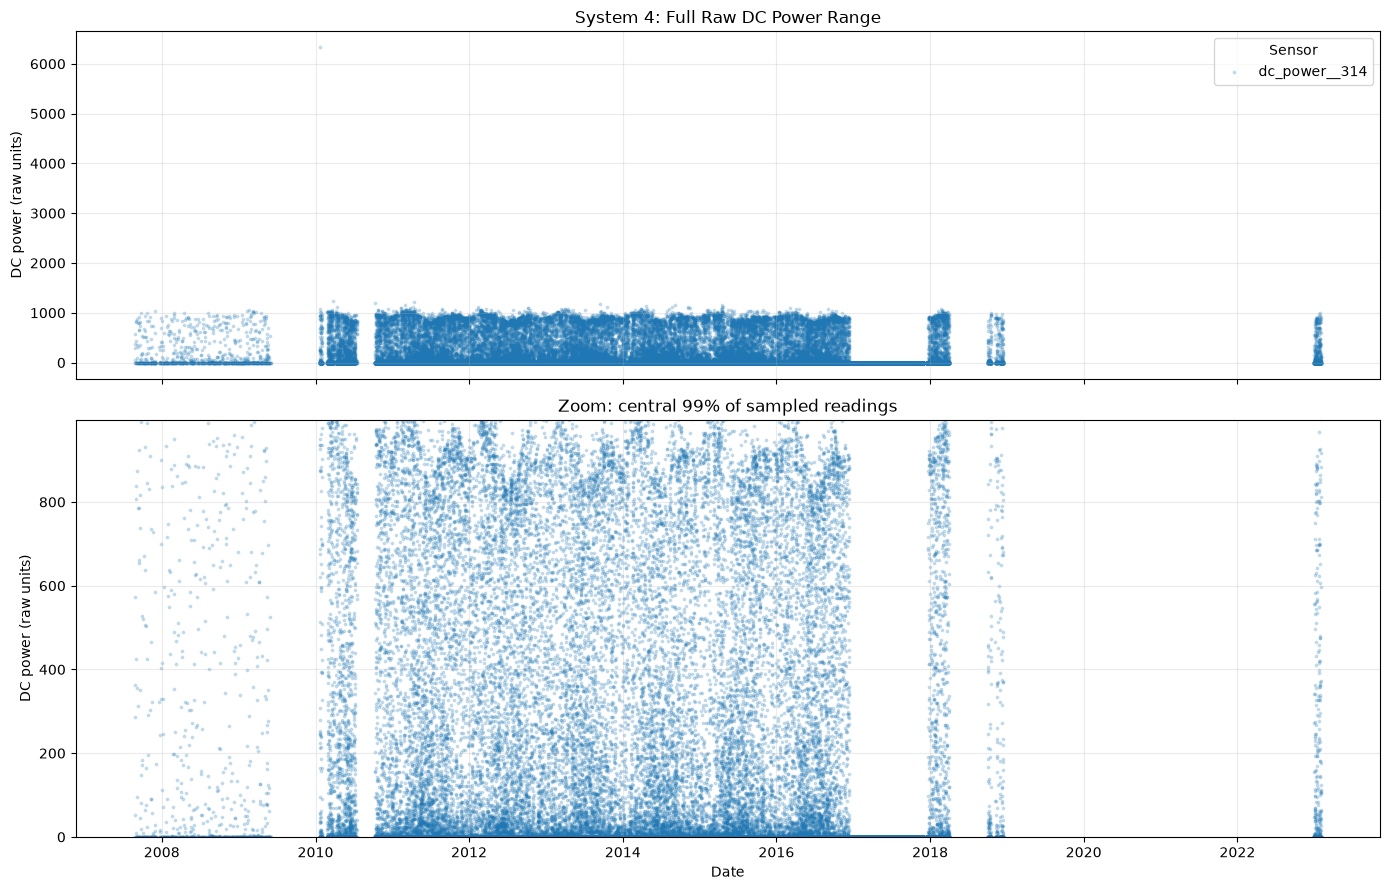

Plotted 60,000 of 4,206,520 projected rows
Sampled points outside the zoomed y-range: 600
Plot saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_raw_dc_power_vs_date.png


In [5]:
# Plot a reproducible sample only; system_df remains unchanged.
MAX_PLOT_POINTS = 60_000
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
PLOT_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_raw_dc_power_vs_date.png"

plot_data = system_df[["datetime", dc_power_column]]
if len(plot_data) > MAX_PLOT_POINTS:
    plot_data = plot_data.sample(n=MAX_PLOT_POINTS, random_state=42)
plot_data = plot_data.sort_values("datetime")
power_values = plot_data[dc_power_column].dropna()
zoom_lower, zoom_upper = power_values.quantile([0.005, 0.995])
outside_zoom = int((~power_values.between(zoom_lower, zoom_upper)).sum())

fig, (full_ax, zoom_ax) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [1, 1.2]}
)
for axis in (full_ax, zoom_ax):
    axis.scatter(plot_data["datetime"], plot_data[dc_power_column], s=3, alpha=0.2,
                 rasterized=True, label=dc_power_column)
    axis.set_ylabel("DC power (raw units)")
    axis.grid(True, alpha=0.25)

full_ax.set_title(f"System {SYSTEM_ID}: Full Raw DC Power Range")
full_ax.legend(title="Sensor")
zoom_ax.set_title("Zoom: central 99% of sampled readings")
zoom_ax.set_xlabel("Date")
zoom_ax.set_ylim(zoom_lower, zoom_upper)
fig.tight_layout()

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_PATH, dpi=160)
plt.show()
print(f"Plotted {len(plot_data):,} of {len(system_df):,} projected rows")
print(f"Sampled points outside the zoomed y-range: {outside_zoom:,}")
print(f"Plot saved to: {PLOT_PATH}")

## 5. Replace sentinel codes

The values in `SENTINEL_VALUES` represent invalid sensor readings. Replace them with `NaN` in a working copy; the replaced counts are the sentinel report from stage 3. Missing values are not imputed in this stage.

In [6]:
# Start the cleaning pipeline from a copy; system_df remains unchanged.
cleaned_df = system_df.copy()
numeric_columns = cleaned_df.select_dtypes(include="number").columns
cleaned_df[numeric_columns] = cleaned_df[numeric_columns].replace(list(SENTINEL_VALUES), np.nan)

print("Sentinel values replaced with NaN:")
display(raw_sentinel_report)
print(f"Shape after sentinel replacement: {cleaned_df.shape}")

Sentinel values replaced with NaN:


,-99999,-7999
ambient_temp__320,0,12
dc_pos_current__317,0,1
dc_power__314,0,1
module_temp_1__321,0,518418
poa_irradiance__313,0,44913


Shape after sentinel replacement: (4206520, 12)


## 6. Correct known sensor units

Apply the documented unit conversions to matching sensor base names (the part before `__`). Temperature, half-watt power and power-factor conversions apply only to the systems listed in their constants. The change table shows which conversions ran; for system 4 none apply.

In [7]:
# System-specific conversion configuration for this stage.
FAHRENHEIT_SYSTEMS = {34, 35, 1200, 1276, 1277}
HALF_WATT_POWER_SYSTEMS = {34, 35, 1276, 1277}
POWER_FACTOR_SYSTEMS = {34, 35}
WIND_SPEED_CONVERSION = 0.447

# sensor base name -> (systems it applies to, or None for all; label; conversion)
conversions = {
    "ambient_temp_F": (FAHRENHEIT_SYSTEMS, "fahrenheit_to_celsius", lambda v: (v - 32) * (5 / 9)),
    "module_temp_F": (FAHRENHEIT_SYSTEMS, "fahrenheit_to_celsius", lambda v: (v - 32) * (5 / 9)),
    "dc_power_hW": (HALF_WATT_POWER_SYSTEMS, "divide_by_two_to_watts", lambda v: v / 2),
    "power_factor_1000": (POWER_FACTOR_SYSTEMS, "divide_by_1000", lambda v: v / 1000),
    "wind_speed_mph": (None, "miles_per_hour_to_meters_per_second",
                       lambda v: v * WIND_SPEED_CONVERSION),
}

unit_changes = []
for column in cleaned_df.columns:
    sensor_name = column.split("__", maxsplit=1)[0]
    if sensor_name not in conversions:
        continue
    systems, label, convert = conversions[sensor_name]
    if systems is None or SYSTEM_ID in systems:
        cleaned_df[column] = convert(cleaned_df[column])
        unit_changes.append({"column": column, "conversion": label,
                             "values_converted": int(cleaned_df[column].notna().sum())})

unit_changes = pd.DataFrame(unit_changes, columns=["column", "conversion", "values_converted"])
print("Unit conversions applied:")
display(unit_changes)

Unit conversions applied:


,column,conversion,values_converted


## 7. Remove readings below the power floor

Drop rows only when a non-missing primary DC-power reading is less than `MIN_DC_POWER_W`. Missing target values are preserved here for a separate missing-target decision; readings exactly at the threshold remain.

In [8]:
# Minimum output setting for this stage.
MIN_DC_POWER_W = 20.0

rows_before_floor = len(cleaned_df)
below_floor = cleaned_df[dc_power_column].lt(MIN_DC_POWER_W)  # NaN is never below the floor
cleaned_df = cleaned_df.loc[~below_floor].copy()

print(f"Rows before floor: {rows_before_floor:,}")
print(f"Rows removed below {MIN_DC_POWER_W:g} W: {int(below_floor.sum()):,}")
print(f"Rows after floor: {len(cleaned_df):,}")
print(f"Rows with missing DC power preserved: {cleaned_df[dc_power_column].isna().sum():,}")

Rows before floor: 4,206,520
Rows removed below 20 W: 2,606,809
Rows after floor: 1,599,711
Rows with missing DC power preserved: 3


## 8. Remove high DC-power outliers

Calculate the median from non-missing DC-power readings after the floor stage. Remove values strictly greater than `OUTLIER_MEDIAN_FACTOR × median`; report the calculated cutoff and removal count so the rule is auditable.

In [9]:
# Outlier multiplier for this stage.
OUTLIER_MEDIAN_FACTOR = 5.0

median_dc_power_w = float(cleaned_df[dc_power_column].median())
outlier_limit_w = median_dc_power_w * OUTLIER_MEDIAN_FACTOR
above_outlier_limit = cleaned_df[dc_power_column].gt(outlier_limit_w)
rows_before_outlier_drop = len(cleaned_df)
cleaned_df = cleaned_df.loc[~above_outlier_limit].copy()

print(f"Median after floor: {median_dc_power_w:,.2f} W")
print(f"Outlier cutoff: {OUTLIER_MEDIAN_FACTOR:g} x median = {outlier_limit_w:,.2f} W")
print(f"Rows above cutoff removed: {int(above_outlier_limit.sum()):,}")
print(f"Rows after outlier removal: {len(cleaned_df):,} / {rows_before_outlier_drop:,}")

Median after floor: 390.49 W
Outlier cutoff: 5 x median = 1,952.45 W
Rows above cutoff removed: 82
Rows after outlier removal: 1,599,629 / 1,599,711


## 9. Keep selected features / remove collinearity

List the exact columns to keep in `FEATURES_TO_KEEP`, in output order; every other column is dropped. Every requested name is validated.

In [10]:
# Exact columns to keep, in output order; every other column is dropped.
FEATURES_TO_KEEP = [
    "system_id",
    "datetime",
    "dc_power__314",
    "poa_irradiance__313",
    "module_temp_1__321",
    "ambient_temp__320",
    "das_temp__325",
]

missing_keep_columns = sorted(set(FEATURES_TO_KEEP) - set(cleaned_df.columns))
if missing_keep_columns:
    raise KeyError(f"Requested feature columns not found: {missing_keep_columns}")

dropped_columns = [column for column in cleaned_df.columns if column not in FEATURES_TO_KEEP]
cleaned_df = cleaned_df[FEATURES_TO_KEEP].copy()
print(f"Features dropped: {dropped_columns}")
print(f"Rows retained: {len(cleaned_df):,}")
print(f"Columns remaining: {cleaned_df.columns.tolist()}")

Features dropped: ['ac_current__319', 'ac_power__315', 'ac_voltage__318', 'dc_pos_current__317', 'dc_pos_voltage__316']
Rows retained: 1,599,629
Columns remaining: ['system_id', 'datetime', 'dc_power__314', 'poa_irradiance__313', 'module_temp_1__321', 'ambient_temp__320', 'das_temp__325']


## 10. Drop rows with missing values

After the configured feature drops, remove every row that has a missing value (`NaN`, including sentinel codes replaced in stage 5, or `±inf`) in any retained column. This is complete-case filtering, not imputation. The code reports missing values per column and how many rows were removed.

In [11]:
# Treat infinite values as missing so they are dropped with NaNs.
cleaned_df = cleaned_df.replace([np.inf, -np.inf], np.nan)

rows_before_missing_drop = len(cleaned_df)
missing_by_column = cleaned_df.isna().sum()
missing_by_column = missing_by_column[missing_by_column > 0].sort_values(ascending=False)
cleaned_df = cleaned_df.dropna().copy()
rows_removed = rows_before_missing_drop - len(cleaned_df)

print("Missing values by column before row removal:")
display(missing_by_column.rename("missing_values").to_frame())
print(
    f"Rows removed: {rows_removed:,} / {rows_before_missing_drop:,} "
    f"({rows_removed / rows_before_missing_drop * 100:.3f}%)"
)
print(f"Rows retained: {len(cleaned_df):,}")

Missing values by column before row removal:


,missing_values
poa_irradiance__313,135938
module_temp_1__321,44
ambient_temp__320,7
dc_power__314,3
das_temp__325,3


Rows removed: 135,989 / 1,599,629 (8.501%)
Rows retained: 1,463,640


## 11. Review the complete-case dataset

Check the retained rows, DC-power range and columns after the feature drop and complete-case filtering. This is the dataset that will be written to disk.

In [12]:
print(f"Final shape: {cleaned_df.shape[0]:,} rows x {cleaned_df.shape[1]} columns")
print(f"Median after floor: {median_dc_power_w:,.2f} W")
print(f"Outlier cutoff: {outlier_limit_w:,.2f} W")
print(f"Final DC power min/max: {cleaned_df[dc_power_column].min():,.2f} / "
      f"{cleaned_df[dc_power_column].max():,.2f} W")
print(f"Remaining missing values: {int(cleaned_df.isna().sum().sum()):,}")
display(cleaned_df.head())

Final shape: 1,463,640 rows x 7 columns
Median after floor: 390.49 W
Outlier cutoff: 1,952.45 W
Final DC power min/max: 20.00 / 1,322.59 W
Remaining missing values: 0


,system_id,datetime,dc_power__314,poa_irradiance__313,module_temp_1__321,ambient_temp__320,das_temp__325
41,4,2007-08-26 10:15:00,124.768,990.0,51.635,28.936,36.045
42,4,2007-08-26 10:30:00,788.769,963.0,51.005,28.979,36.742
43,4,2007-08-26 10:45:00,748.326,280.0,49.709,29.261,37.172
44,4,2007-08-26 11:00:00,868.251,160.0,53.407,29.433,37.538
45,4,2007-08-26 11:15:00,823.090,949.0,55.088,29.951,38.160


## 12. Save the cleaned CSV

Write the cleaned table to `data/cleaned/` as CSV. This creates a new output file and does not alter the merged input. Rows with missing values were dropped in stage 10, so the output contains no empty fields.

In [13]:
# Output path settings for this save stage.
CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"
OUTPUT_PATH = CLEANED_DIR / f"system_{SYSTEM_ID}_cleaned.csv"
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
cleaned_df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned CSV saved to: {OUTPUT_PATH}")

Cleaned CSV saved to: /home/raul/Desktop/solar-data-all/thesis/data/cleaned/system_4_cleaned.csv


## 13. Visualize cleaned data over time

Plot `Y_FEATURE` against `datetime` after all cleaning stages, for comparison with the raw plot in stage 4. A reproducible sample of up to `MAX_PLOT_POINTS` rows is plotted for speed; `cleaned_df` is not modified.

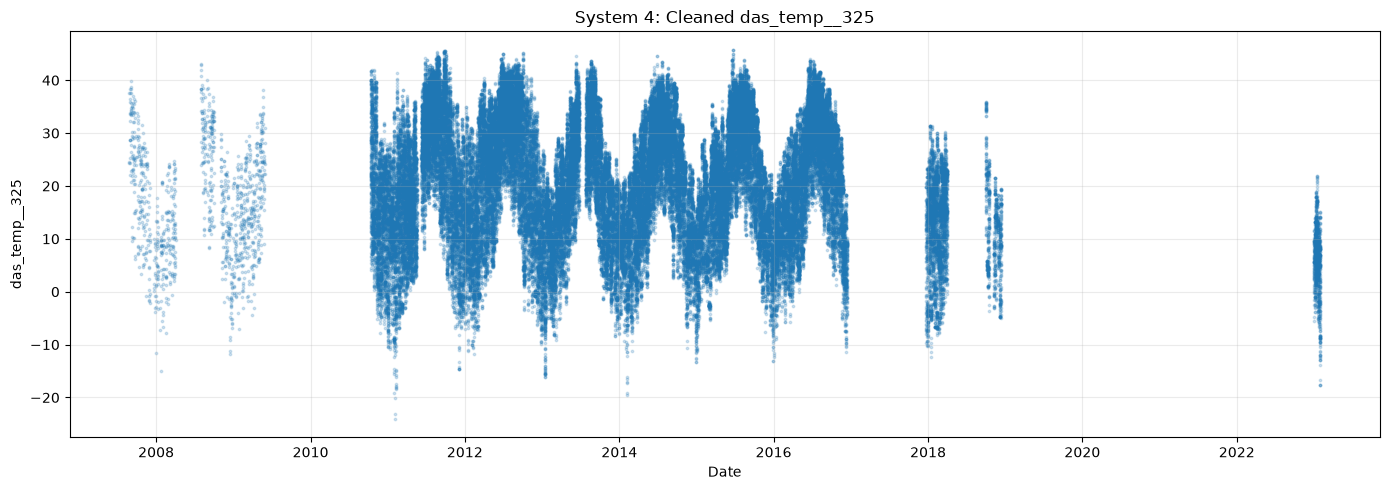

Plotted 100,000 of 1,463,640 cleaned rows
Plot saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_cleaned_das_temp__325_vs_date.png


In [14]:
# Plot settings for this stage.
MAX_PLOT_POINTS = 100_000
Y_FEATURE = "das_temp__325"  # Any column in cleaned_df, e.g. "poa_irradiance__313" or "dc_power__314".

if Y_FEATURE not in cleaned_df.columns:
    raise KeyError(f"Y_FEATURE not found in cleaned_df: {Y_FEATURE}")
CLEANED_PLOT_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_cleaned_{Y_FEATURE}_vs_date.png"

cleaned_plot_data = cleaned_df[["datetime", Y_FEATURE]]
if len(cleaned_plot_data) > MAX_PLOT_POINTS:
    cleaned_plot_data = cleaned_plot_data.sample(n=MAX_PLOT_POINTS, random_state=42)
cleaned_plot_data = cleaned_plot_data.sort_values("datetime")

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(cleaned_plot_data["datetime"], cleaned_plot_data[Y_FEATURE], s=3, alpha=0.2,
           rasterized=True)
ax.set_title(f"System {SYSTEM_ID}: Cleaned {Y_FEATURE}")
ax.set_xlabel("Date")
ax.set_ylabel(Y_FEATURE)
ax.grid(True, alpha=0.25)
fig.tight_layout()

fig.savefig(CLEANED_PLOT_PATH, dpi=160)
plt.show()
print(f"Plotted {len(cleaned_plot_data):,} of {len(cleaned_df):,} cleaned rows")
print(f"Plot saved to: {CLEANED_PLOT_PATH}")